In [ ]:
import firedrake as fd
import gmsh as gm
import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
from firedrake.output import VTKFile
from firedrake.__future__ import interpolate

# **Weak form of the homogeneous Poisson problem in the primal formulation**

We begin by recalling the Poisson problem in its strong form. Let $\Omega$ be an open, bounded, connected subset of Euclidean space $\mathbb{R}^n$, where $n = 1, 2,$ or $3$, with a Lipschitz continuous boundary $\Gamma = \partial \Omega$. Given a function $f: \Omega \to \mathbb{R}$ such that $f \in C(\Omega)$, and a coefficient $\mu: \Omega \to \mathbb{R}$ such that $\mu \in C^1(\Omega)$ and $\mu(\mathbf{x}) > 0$ for all $\mathbf{x} \in \Omega$, find $u: \bar{\Omega} \to \mathbb{R}$ such that $u \in C^2(\Omega) \cap C(\bar{\Omega})$ satisfying:

\begin{equation}
  \begin{cases}
  \begin{aligned}
  -\nabla \cdot (\mu(\mathbf{x}) \nabla u(\mathbf{x})) &= f(\mathbf{x}) &&\quad \text{in } \quad \Omega, \\
  u(\mathbf{x}) &= 0 &&\quad \text{on } \quad \partial \Omega.
  \end{aligned}
  \end{cases}
\end{equation}

We aim to construct the variational or weak form of the previous problem. To do this, we first recall the Sobolev space

\begin{equation}
  H^1(\Omega) = \left\{ v \in L^2(\Omega) : \frac{\partial v}{\partial x_i} \in L^2(\Omega), \ i = 1, \dots, n \right\}, \qquad \|v\|_{H^1(\Omega)}^2 = \|v\|_{L^2(\Omega)}^2 + \|\nabla v\|_{L^2(\Omega)}^2,
\end{equation}

where the derivatives are understood in the weak sense, and its subspace of functions that vanish on the boundary (in the sense of traces):

\begin{equation}
  H^1_0(\Omega) = \left\{ v \in H^1(\Omega) : v = 0 \text{ on } \partial \Omega \right\}.
\end{equation}

We then define a sufficiently regular function (also called a test function), $v: \bar{\Omega} \rightarrow \mathbb{R}$ such that $v \in V(\Omega)$, where $V(\Omega) = H^1_0(\Omega)$, that is:

\begin{equation}
  v(\mathbf{x}) = 0, \quad \forall \mathbf{x} \in \partial \Omega.
\end{equation}

We then multiply both sides of the elliptic PDE by $v(\mathbf{x})$ and integrate over $\Omega$:

\begin{equation}
  -\int_{\Omega}\nabla \cdot (\mu(\mathbf{x}) \nabla u(\mathbf{x})) v(\mathbf{x}) \, dx = \int_{\Omega} f(\mathbf{x}) v(\mathbf{x}) \, dx.
\end{equation}

Assuming that $u$ and $\mu$ are regular enough up to the boundary, we integrate by parts on the left-hand side and get: $^1$

\begin{equation}
  \begin{aligned}
  \int_{\Omega} \mu \nabla u \cdot \nabla v \, dx - \int_{\Omega}\nabla \cdot (v \mu \nabla u) \, dx &= \int_{\Omega} f v \, dx, \\
  \int_{\Omega} \mu \nabla u \cdot \nabla v \, dx - \int_{\partial \Omega} v (\mu \nabla u) \cdot \mathbf{\hat{n}} \, ds &= \int_{\Omega} f v \, dx, \quad \text{by the divergence theorem}, \\
  \int_{\Omega} \mu \nabla u \cdot \nabla v \, dx &= \int_{\Omega} f v \, dx, \quad \text{since } v = 0 \text{ on } \partial \Omega.
  \end{aligned}
\end{equation}

Thus, assuming $f \in L^2(\Omega)$ and $0 < \mu_{\min} \le \mu(\mathbf{x}) \le \mu_{\max}$ in $\Omega$, the weak form of Poisson's problem is: find $u \in V(\Omega)$ such that:

\begin{equation}
  \int_{\Omega} \mu \nabla u \cdot \nabla v \, dx = \int_{\Omega} f v \, dx, \quad \forall v \in V(\Omega),
\end{equation}

or, in the abstract form: find $u \in V(\Omega)$ such that:

\begin{equation}
  a(u,v) = \ell(v), \quad \forall v \in V(\Omega),
\end{equation}

where the bilinear and linear forms $^2$ are given respectively by:

\begin{equation}
  \begin{aligned}
  a(u,v) &= \int_{\Omega} \mu \nabla u \cdot \nabla v \, dx, \\
  \ell(v) &= \int_{\Omega} f v \, dx.
  \end{aligned}
\end{equation}

We now proceed to the discrete variational problem. Defining a certain discrete finite element space $V_{h}(\Omega) \subset V(\Omega)$, the abstract variational problem can be rewritten as follows: find $u_{h} \in V_{h}(\Omega)$ such that:

\begin{equation}
  a(u_{h},v_{h}) = \ell(v_{h}), \quad \forall v_{h} \in V_{h}(\Omega).
\end{equation}

For our particular case, $V_{h}(\Omega)$ can be, for example, the space of continuous piecewise linear functions that vanish on $\partial \Omega$. Given a triangulation $\mathcal{T}_h$ of $\Omega$, we define

\begin{equation}
  \text{CG}_1 = \left\{ v_h \in C(\bar{\Omega}) : v_h|_K \in \mathbb{P}_1(K), \ \forall K \in \mathcal{T}_h \right\},
\end{equation}

where $\mathbb{P}_1(K)$ denotes the polynomials of degree at most one on the element $K$, and

\begin{equation}
  V_h(\Omega) = \left\{ v_h \in \text{CG}_1 : v_h = 0 \text{ on } \partial \Omega \right\}.
\end{equation}

That is, $V_{h}(\Omega)$ is the space $\text{CG}_{1}$ with homogeneous Dirichlet boundary conditions.

Let $\{\varphi_j\}_{j=1}^{N_h}$ be the nodal basis of $V_h(\Omega)$, where $\varphi_j(\mathbf{x}_i) = \delta_{ij}$ at the interior mesh nodes $\mathbf{x}_i$. Writing $u_h = \sum_{j=1}^{N_h} U_j \varphi_j$ and taking $v_h = \varphi_i$, $i = 1, \dots, N_h$, the discrete problem is equivalent to the linear system

\begin{equation}
  \mathbf{A}\mathbf{U} = \mathbf{F}, \qquad A_{ij} = a(\varphi_j, \varphi_i), \qquad F_i = \ell(\varphi_i).
\end{equation}

The matrix $\mathbf{A}$ is symmetric, since $a(\cdot,\cdot)$ is symmetric, positive definite, since $\mu > 0$, and sparse, since each $\varphi_j$ is nonzero only on the elements that share the node $\mathbf{x}_j$.

In the post-processing of the solution, we also use the space of piecewise constant functions:

\begin{equation}
  \text{DG}_0 = \left\{ w_h \in L^2(\Omega) : w_h|_K \in \mathbb{P}_0(K), \ \forall K \in \mathcal{T}_h \right\},
\end{equation}

where $\mathbb{P}_0(K)$ denotes the constant functions on the element $K$. Unlike $\text{CG}_1$, the functions in $\text{DG}_0$ are not required to be continuous across the element boundaries, so $\text{DG}_0 \not\subset H^1(\Omega)$ and it cannot be used as $V_h(\Omega)$ in the weak form above. It is, however, a natural space to represent quantities that are discontinuous between elements, such as the gradient of $u_h \in \text{CG}_1$, which is constant on each element.

$\textbf{Remarks:}$

$\mathbf{1:}$ For convenience, we omit the $\mathbf{x}$ dependence to simplify the notation.

$\mathbf{2:}$ Here, we verify that the bilinear form $a(\cdot,\cdot): V \times V \rightarrow \mathbb{R}$ is linear in both arguments. To do this, we must verify that for all $u,v, w \in V$ and $\alpha, \beta \in \mathbb{R}$:

\begin{equation}
  \begin{aligned}
  a(\alpha u + \beta v, w) &= \alpha a(u,w) + \beta a(v,w), \\
  a(u, \alpha v + \beta w) &= \alpha a(u,v) + \beta a(u,w).
  \end{aligned}
\end{equation}

We prove only the first case; the second follows analogously.

\begin{equation}
  \begin{aligned}
  a(\alpha u + \beta v, w) &= \int_{\Omega} \mu \nabla(\alpha u + \beta v) \cdot \nabla w \, dx \\
  &= \int_{\Omega} \mu (\alpha \nabla u + \beta \nabla v) \cdot \nabla w \, dx \\
  &= \int_{\Omega} [\alpha \mu ( \nabla u \cdot \nabla w) + \beta \mu ( \nabla v \cdot \nabla w) ] \, dx \\
  &= \alpha \int_{\Omega} \mu \nabla u \cdot \nabla w \, dx + \beta \int_{\Omega} \mu \nabla v \cdot \nabla w \, dx \\
  &= \alpha a(u,w) + \beta a(v,w).
  \end{aligned}
\end{equation}

We also need to prove that the linear form $\ell(\cdot): V \rightarrow \mathbb{R}$ is indeed linear. Thus, we need to verify that for all $u,v \in V$ and $\alpha, \beta \in \mathbb{R}$:

\begin{equation}
  \ell(\alpha u + \beta v) = \alpha \ell(u) + \beta \ell(v).
\end{equation}

By our definition of the linear form, we obtain:

\begin{equation}
  \begin{aligned}
  \ell(\alpha u + \beta v) &= \int_{\Omega} f (\alpha u + \beta v) \, dx \\
  &= \int_{\Omega} [\alpha (fu) + \beta (fv)] \, dx \\
  &= \alpha \int_{\Omega} (fu) \, dx + \beta \int_{\Omega} (fv) \, dx \\
  &= \alpha \ell(u) + \beta \ell(v).
  \end{aligned}
\end{equation}

# **Rectangular domain using Firedrake**



---

**Some comments about the implementation:**


1. To investigate the effect of $\mu(\mathbf{x})$ on the solution of the elliptic partial differential equation, we propose two different functions for it: in the first case, we assume $\mu(\mathbf{x}) = 1, \forall \mathbf{x} \in \Omega$; in the second case, we assume $\mu(\mathbf{x})$ is a Gaussian function, given by:

\begin{equation}
  \mu(\mathbf{x}) = A + e^{-B\left[ \left(x-\frac{1}{2}\right)^{2} + \left(y-\frac{1}{2}\right)^{2} \right]}
\end{equation}

where $A, B \in \mathbb{R}_{+}$;

2. Once we've obtained the numerical solution for the potential function $u(\mathbf{x})$, we compute the shear stresses $\boldsymbol{\tau} = \mu(\mathbf{x}) \nabla u(\mathbf{x})$, and we plot the norm $\|\boldsymbol{\tau}\|_{2} = \sqrt{ \boldsymbol{\tau} \cdot \boldsymbol{\tau}}$ as a scalar field in $\text{DG}_{0}$, i.e., the space of elementwise constant functions;

3. Finally, we compute the wall shear stresses $ \tilde{\boldsymbol{\sigma}} \cdot \mathbf{\hat{n}} = (\boldsymbol{\tau} \cdot \mathbf{\hat{n}}) \mathbf{\hat{e}_{3}}$, where $\mathbf{\hat{e}_{3}}$ is the unit vector in the z-direction, by integrating over the boundary:

\begin{equation}
  W_{ss} = \int_{\partial \Omega} \boldsymbol{\tau} \cdot \mathbf{\hat{n}} \, ds.
\end{equation}




In [ ]:
def solver_poisson(mesh, domain_geo,mu_expression, flag_gmsh = False):

  # Extract the spatial domain coordinates
  x  = fd.SpatialCoordinate(mesh)

  # Finite element space
  CG1 = fd.FunctionSpace(mesh, "CG", degree = 1)  # Continuous pieciwise linear functions
  DG0 = fd.FunctionSpace(mesh, "DG", degree = 0)  # Discontinuous pieciwise constant functions

  # Test and Trial functions
  u = fd.TrialFunction(CG1)
  v = fd.TestFunction(CG1)

  # Boundary conditions
  u_boundary = fd.Constant(0.0)
  bc = fd.DirichletBC(CG1, u_boundary, "on_boundary")

  # Source term
  f = fd.Constant(1.0)

  # Permeability
  if mu_expression == 'constant':
    mu_exp = fd.Constant(1.0)
    mu = fd.Function(CG1)
    mu.interpolate(mu_exp)

  elif mu_expression == 'gaussian':
    mu = fd.Function(CG1)
    A = fd.Constant(0.01)
    B = fd.Constant(100)

    if domain_geo == 'square':
      mu_exp = A + fd.exp(-B*((x[0]-0.5)**2 + (x[1]-0.5)**2))
      mu.interpolate(mu_exp)

    elif domain_geo == 'disk':
      mu_exp = A + fd.exp(-B*((x[0])**2 + (x[1])**2))
      mu.interpolate(mu_exp)

    else:
      raise ValueError("domain_geo not recognized")

  else:
    raise ValueError("mu_expression not recognized")

  # Bilinear form (lhs) and linear form (rhs)
  a  = fd.inner(mu_exp * fd.grad(u), fd.grad(v)) * fd.dx
  L  = fd.inner(f, v) * fd.dx

  # Solve the problem
  uh = fd.Function(CG1)
  opts={"ksp_type": "preonly", "pc_type": "lu"}
  fd.solve(a==L, uh, bcs=[bc], solver_parameters=opts)

  # Compute the shear stress
  tau = mu_exp*fd.grad(uh)
  tau_norm2 = fd.project(fd.sqrt(fd.inner(tau,tau)), DG0)

  # Compute the wall shear stress
  n = fd.FacetNormal(mesh)
  Wss = (fd.inner(tau,n) * fd.ds if flag_gmsh == False else fd.inner(tau,n) * fd.ds(0))
  # print(f'Wall shear stress: {fd.assemble(Wss)}')

  # Computing some norms
  # Using firedrake functions
  uh_L2 = fd.norm(uh, 'L2')
  uh_H1 = fd.norm(uh, 'H1')

  # Programming manually
  L2_norm = np.sqrt(fd.assemble(fd.inner(uh,uh)*fd.dx))
  # H1_norm = np.sqrt(fd.assemble((fd.inner(uh,uh) + fd.inner(fd.grad(uh),fd.grad(uh)))*fd.dx))
  H1_norm = np.sqrt(fd.assemble((fd.inner(uh,uh) + uh.dx(0)**2 + uh.dx(1)**2)*fd.dx))

  return uh, mu, tau_norm2 , Wss, uh_L2, uh_H1, L2_norm, H1_norm


Computing some norm: ractangular domain with constant permeability

In [8]:
# Define the finite element mesh
Lx, Ly = 1, 1
Nmesh = [8, 16, 32, 64, 128, 256]
h = [Lx/N for N in Nmesh]
# Define the domain geometry
domain_geo = 'square'
# Define the function for the permeability field
mu_expression = 'constant'

# Define empty lists to store the norm of the computed solution
uh_L2_list = []
uh_H1_list = []

# Iterate over some finite element mesh discretizations
for N in Nmesh:
  # Construct the finite element mesh
  mesh = fd.RectangleMesh(N, N, Lx, Ly, quadrilateral=False)
  # Call the function
  uh, mu, tau_norm2 , Wss, uh_L2, uh_H1, L2_norm, H1_norm = solver_poisson(mesh, domain_geo, mu_expression, flag_gmsh = False)
  # Store some values for post processing
  uh_L2_list.append(uh_L2)
  uh_H1_list.append(uh_H1)

  print(f'|> ... Solved for N={N} ... <|')

|> ... Solved for N=8 ... <|
|> ... Solved for N=16 ... <|
|> ... Solved for N=32 ... <|
|> ... Solved for N=64 ... <|
|> ... Solved for N=128 ... <|
|> ... Solved for N=256 ... <|


Summarize the obtained results

In [9]:
head = ['N', 'h', '||uh||_L2', '||uh||_H1']
table = [[N, h, uh_L2, uh_H1] for N, h, uh_L2, uh_H1 in zip(Nmesh, h, uh_L2_list, uh_H1_list)]
print(tabulate(table, headers=head, tablefmt="fancy_grid"))
# df  = pd.DataFrame(table, columns=head)
# display(df)

╒═════╤════════════╤═════════════╤═════════════╕
│   N │          h │   ||uh||_L2 │   ||uh||_H1 │
╞═════╪════════════╪═════════════╪═════════════╡
│   8 │ 0.125      │   0.039653  │    0.187071 │
├─────┼────────────┼─────────────┼─────────────┤
│  16 │ 0.0625     │   0.0408527 │    0.190714 │
├─────┼────────────┼─────────────┼─────────────┤
│  32 │ 0.03125    │   0.0411589 │    0.191643 │
├─────┼────────────┼─────────────┼─────────────┤
│  64 │ 0.015625   │   0.0412358 │    0.191877 │
├─────┼────────────┼─────────────┼─────────────┤
│ 128 │ 0.0078125  │   0.0412551 │    0.191936 │
├─────┼────────────┼─────────────┼─────────────┤
│ 256 │ 0.00390625 │   0.0412599 │    0.19195  │
╘═════╧════════════╧═════════════╧═════════════╛


Visualize all the unknown fields

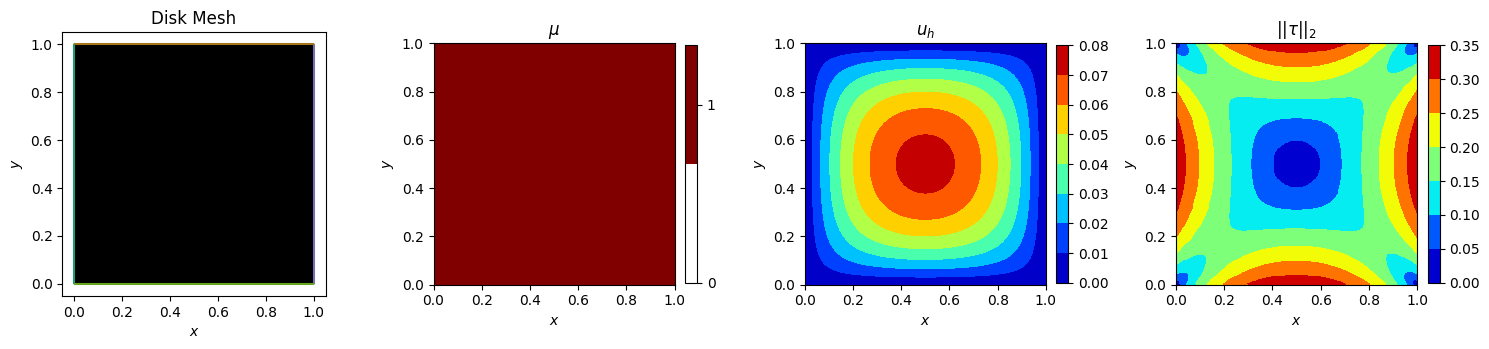

In [10]:
# Visualization
fig, ax = plt.subplots(1, 4, figsize=(15, 5), dpi=100)

# Plot the mesh
fd.pyplot.triplot(mesh, axes=ax[0])
ax[0].set_title('Disk Mesh')
ax[0].set_aspect('equal')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$y$')

# Plot the viscosity function
contours_mu = fd.pyplot.tricontourf(mu, axes=ax[1], cmap="jet", vmin=(0 if mu_expression == 'constant' else None),
                                    vmax=(1 if mu_expression == 'constant' else None))
cbar_mu = plt.colorbar(contours_mu, ax=ax[1], fraction=0.045, pad=0.04)
cbar_mu.set_ticks([0, 1]) if mu_expression == 'Constant' else None
ax[1].set_title('$\\mu$')
ax[1].set_aspect('equal')
ax[1].set_xlabel('$x$')
ax[1].set_ylabel('$y$')

# Plot the solution uh
contours_uh = fd.pyplot.tricontourf(uh, axes=ax[2],cmap="jet")
cbar_uh = plt.colorbar(contours_uh, ax=ax[2],fraction=0.045, pad=0.04)
ax[2].set_title('$u_{h}$')
ax[2].set_aspect('equal')
ax[2].set_xlabel('$x$')
ax[2].set_ylabel('$y$')

# Plot the shear stress norm
contours_tau = fd.pyplot.tricontourf(tau_norm2, axes=ax[3],cmap="jet")
cbar_tau = plt.colorbar(contours_tau, ax=ax[3], fraction=0.045, pad=0.04)
ax[3].set_title('$||\\tau||_{2}$')
ax[3].set_aspect('equal')
ax[3].set_xlabel('$x$')
ax[3].set_ylabel('$y$')

# Improve layout
plt.tight_layout()
plt.show()


# Save the results for further visualization in Paraview
# uh.rename('uh')
# VTKFile("Results/uh.pvd").write(uh)
# tau_norm2.rename('\tau_{2}')
# VTKFile("Results/Vstress.pvd").write(tau_norm2)


# **Considering a gaussian permeability field**

In [ ]:
# Define the finite element mesh
Lx, Ly = 1, 1
Nmesh = [8, 16, 32, 64, 128, 256]
h = [Lx/N for N in Nmesh]
# Define the domain geometry
domain_geo = 'square'
# Define the function for the permeability field
mu_expression = 'gaussian'

# Define empty lists to store the norm of the computed solution
uh_L2_list = []
uh_H1_list = []

# Iterate over some finite element mesh discretizations
for N in Nmesh:
  # Construct the finite element mesh
  mesh = fd.RectangleMesh(N, N, Lx, Ly, quadrilateral=False)
  # Call the function
  uh, mu, tau_norm2 , Wss, uh_L2, uh_H1, L2_norm, H1_norm = solver_poisson(mesh, domain_geo, mu_expression, flag_gmsh = False)
  # Store some values for post processing
  uh_L2_list.append(uh_L2)
  uh_H1_list.append(uh_H1)

  print(f'|> ... Solved for N={N} ... <|')

|> ... Solved for N=8 ... <|
|> ... Solved for N=16 ... <|
|> ... Solved for N=32 ... <|
|> ... Solved for N=64 ... <|
|> ... Solved for N=128 ... <|
|> ... Solved for N=256 ... <|


In [ ]:
head = ['N', 'h', '||uh||_L2', '||uh||_H1']
table = [[N, h, uh_L2, uh_H1] for N, h, uh_L2, uh_H1 in zip(Nmesh, h, uh_L2_list, uh_H1_list)]
print(tabulate(table, headers=head, tablefmt="fancy_grid"))
# df  = pd.DataFrame(table, columns=head)
# display(df)

╒═════╤════════════╤═════════════╤═════════════╕
│   N │          h │   ||uh||_L2 │   ||uh||_H1 │
╞═════╪════════════╪═════════════╪═════════════╡
│   8 │ 0.125      │     3.73873 │     18.1443 │
├─────┼────────────┼─────────────┼─────────────┤
│  16 │ 0.0625     │     3.91238 │     18.6384 │
├─────┼────────────┼─────────────┼─────────────┤
│  32 │ 0.03125    │     3.95603 │     18.7685 │
├─────┼────────────┼─────────────┼─────────────┤
│  64 │ 0.015625   │     3.967   │     18.801  │
├─────┼────────────┼─────────────┼─────────────┤
│ 128 │ 0.0078125  │     3.96976 │     18.8091 │
├─────┼────────────┼─────────────┼─────────────┤
│ 256 │ 0.00390625 │     3.97044 │     18.8112 │
╘═════╧════════════╧═════════════╧═════════════╛


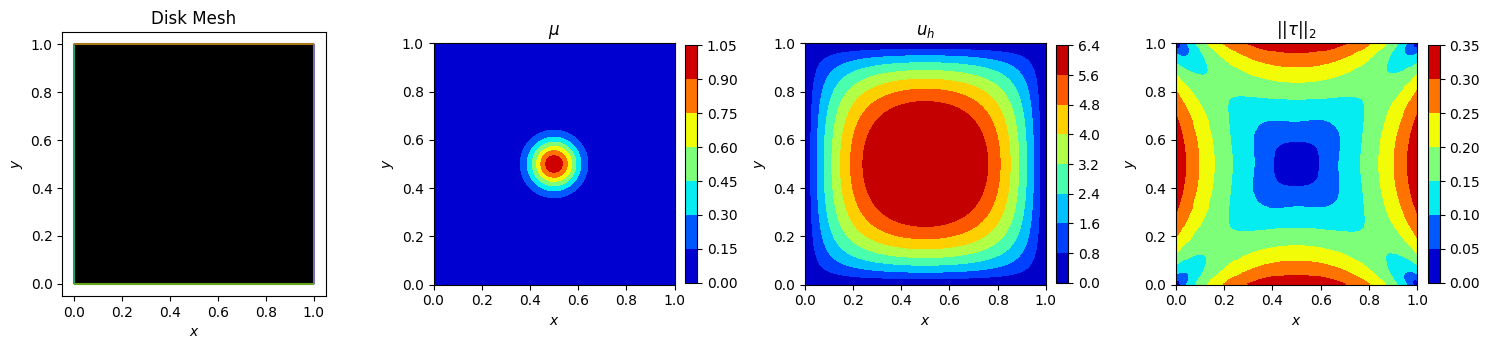

In [ ]:
# Visualization
fig, ax = plt.subplots(1, 4, figsize=(15, 5), dpi=100)

# Plot the mesh
fd.pyplot.triplot(mesh, axes=ax[0])
ax[0].set_title('Disk Mesh')
ax[0].set_aspect('equal')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$y$')

# Plot the viscosity function
contours_mu = fd.pyplot.tricontourf(mu, axes=ax[1], cmap="jet", vmin=(0 if mu_expression == 'constant' else None),
                                    vmax=(1 if mu_expression == 'constant' else None))
cbar_mu = plt.colorbar(contours_mu, ax=ax[1], fraction=0.045, pad=0.04)
cbar_mu.set_ticks([0, 1]) if mu_expression == 'constant' else None
ax[1].set_title('$\\mu$')
ax[1].set_aspect('equal')
ax[1].set_xlabel('$x$')
ax[1].set_ylabel('$y$')

# Plot the solution uh
contours_uh = fd.pyplot.tricontourf(uh, axes=ax[2],cmap="jet")
cbar_uh = plt.colorbar(contours_uh, ax=ax[2],fraction=0.045, pad=0.04)
ax[2].set_title('$u_{h}$')
ax[2].set_aspect('equal')
ax[2].set_xlabel('$x$')
ax[2].set_ylabel('$y$')

# Plot the shear stress norm
contours_tau = fd.pyplot.tricontourf(tau_norm2, axes=ax[3],cmap="jet")
cbar_tau = plt.colorbar(contours_tau, ax=ax[3], fraction=0.045, pad=0.04)
ax[3].set_title('$||\\tau||_{2}$')
ax[3].set_aspect('equal')
ax[3].set_xlabel('$x$')
ax[3].set_ylabel('$y$')

# Improve layout
plt.tight_layout()
plt.show()


# Save the results for further visualization in Paraview
# uh.rename('uh')
# VTKFile("Results/uh.pvd").write(uh)
# tau_norm2.rename('\tau_{2}')
# VTKFile("Results/Vstress.pvd").write(tau_norm2)


# **Define a certain velocity field and compute the norm**

In [ ]:
# Define the finite element mesh
Lx, Ly = 1, 1
Nx, Ny = 64, 64
mesh = fd.RectangleMesh(Nx, Ny, Lx, Ly, quadrilateral=False)
x = fd.SpatialCoordinate(mesh)

# Define the vector velocity field
u = fd.as_vector([fd.sin(x[0]*fd.sin(x[1])),fd.cos(x[0]*fd.cos(x[1]))])

# Compute L2 and H1 norm of the previous velocity field
u_L2norm = np.sqrt(fd.assemble(fd.inner(u,u)*fd.dx))
u_H1norm = np.sqrt(fd.assemble((fd.inner(u,u) + fd.inner(fd.grad(u),fd.grad(u)))*fd.dx))
u_H1norm = np.sqrt(fd.assemble((fd.inner(u,u) + u.dx(0)**2 + u.dx(1)**2)*fd.dx))

print(f'||u||_L2 = {np.round(u_L2norm,5)}')
print(f'||u||_H1 = {np.round(u_H1norm,5)}')


||u||_L2 = 0.93606
||u||_H1 = 1.23113


# **Observe orthogonality between some functions**

In [ ]:
def orthogonality(m,n):
  # Define limits of the interval
  Xi, Xf = -np.pi, np.pi
  # Define the number of elements
  N = 64
  # Define the finite element mesh
  mesh = fd.IntervalMesh(N, Xi, Xf)
  # Extract the coordinates
  x = fd.SpatialCoordinate(mesh)

  # Define the finite element space
  CG1 = fd.FunctionSpace(mesh, "CG", degree = 1)

  # Define the two functions
  u, v =  fd.Function(CG1), fd.Function(CG1)
  u.interpolate(fd.sin(m*x[0]))
  v.interpolate(fd.sin(n*x[0]))

  # Compute the L2-inner product of u and v
  uv_L2inner = fd.assemble(fd.inner(u,v)*fd.dx)

  # Extract the values of x, u and v
  x_values = mesh.coordinates.dat.data
  u_values = u.dat.data
  v_values = v.dat.data

  return x_values, u_values, v_values, uv_L2inner


m_list, n_list = [1, 2], [1,2]
x, u, v, uvL2inner = [], [], [], []

for m in m_list:
  for n in n_list:
    x_values, u_values, v_values, uv_L2inner = orthogonality(m,n)
    x.append(x_values)
    u.append(u_values)
    v.append(v_values)
    uvL2inner.append(uv_L2inner)
    print(f'|> ... Solved for m={m}, n={n} ... <|')



|> ... Solved for m=1, n=1 ... <|
|> ... Solved for m=1, n=2 ... <|
|> ... Solved for m=2, n=1 ... <|
|> ... Solved for m=2, n=2 ... <|


In [ ]:
# Summarize the values
head = ['-','m=1', 'm=2']
table = [np.hstack((['n=1'],uvL2inner[:2])), np.hstack((['n=2'],uvL2inner[2:]))]
print(tabulate(table, headers=head, tablefmt="fancy_grid"))


╒═════╤══════════════╤══════════════╕
│ -   │          m=1 │          m=2 │
╞═════╪══════════════╪══════════════╡
│ n=1 │  3.13655     │ -1.72622e-17 │
├─────┼──────────────┼──────────────┤
│ n=2 │ -1.72622e-17 │  3.12147     │
╘═════╧══════════════╧══════════════╛


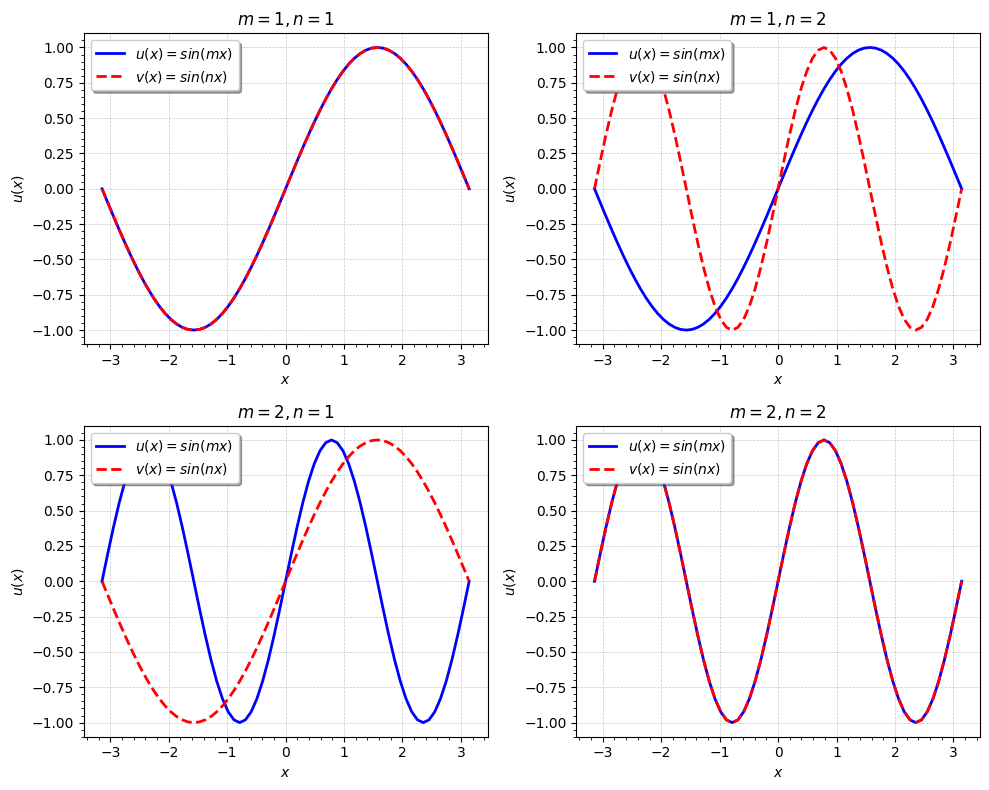

In [ ]:
# Plot
uline = dict(linestyle = '-', color = 'b', linewidth = 2.0,)
vline = dict(linestyle = '--', color = 'r', linewidth = 2.0)
fig, ax = plt.subplots(2,2, figsize=(10, 8))
ax = ax.flatten()
for i in range(len(x)):
  ax[i].plot(x[i], u[i], **uline, label = r'$u(x) = sin(mx)$')
  ax[i].plot(x[i], v[i],  **vline, label = r'$v(x) = sin(nx)$')
  ax[i].set_title(f'$m = {m_list[i // len(m_list)]}, n = {n_list[i%len(n_list)]}$')
  ax[i].set_xlabel('$x$')
  ax[i].set_ylabel('$u(x)$')
  ax[i].legend(loc='upper left', fancybox = True, shadow = True)
  ax[i].grid(linestyle='--', linewidth=0.5, alpha=0.7)
  ax[i].minorticks_on()
plt.tight_layout()
plt.show()